In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Flight_Booking.csv")

In [3]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [4]:
#EDA
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [5]:
df.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.drop(columns = ["Unnamed: 0"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [8]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [9]:
df.duplicated().sum()

np.int64(0)

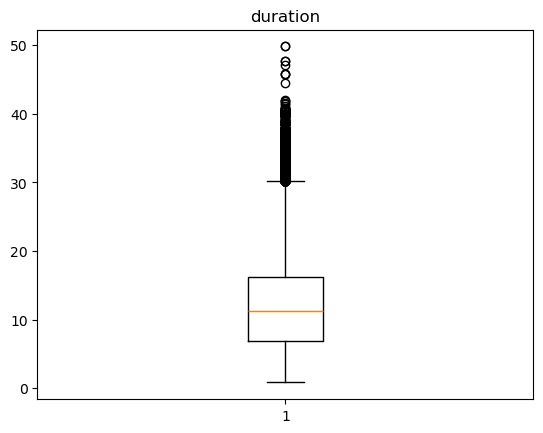

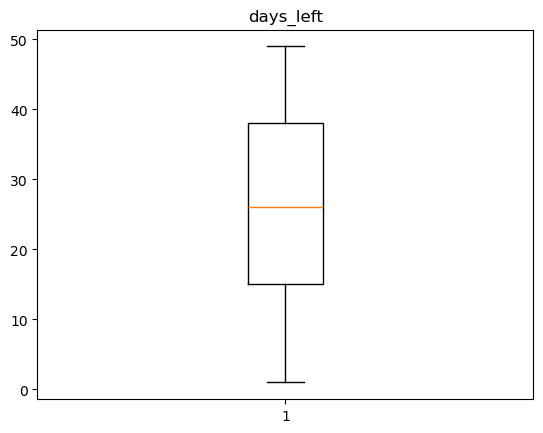

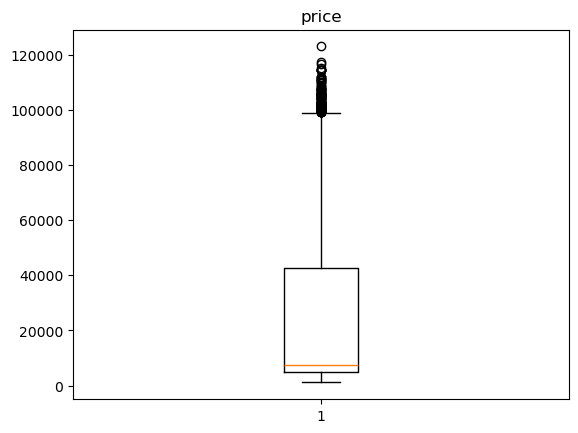

In [10]:
#Visualize outliers
for i in df.columns:
    if df[i].dtype != 'object':
        plt.boxplot(df[i])
        plt.title(i)
        plt.show()

In [11]:
#get the unique values in stops column
df['stops'].unique()

array(['zero', 'one', 'two_or_more'], dtype=object)

In [12]:
df['stops'] = df['stops'].replace({'zero': 0, 'one': 1, 'two_or_more': 2})

C:\Users\Shreyas_Srijith\AppData\Local\Temp\ipykernel_6508\3725190732.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['stops'] = df['stops'].replace({'zero': 0, 'one': 1, 'two_or_more': 2})


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  int64  
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 25.2+ MB


In [14]:
df = df.drop(columns = ["flight"])

In [15]:
#make a dummy data for airline, source_city,departure_time,arrival_time,destination_city,class

categorical_col = ['airline','source_city','departure_time','arrival_time','destination_city','class']

dummy_df = pd.get_dummies(df,columns=categorical_col,drop_first=True)
dummy_df

,stops,duration,days_left,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,0,2.17,1,5953,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,True
1,0,2.33,1,5953,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,True
2,0,2.17,1,5956,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
3,0,2.25,1,5955,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,True
4,0,2.33,1,5955,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,10.08,49,69265,False,False,False,False,True,True,...,True,False,False,False,False,False,True,False,False,False
300149,1,10.42,49,77105,False,False,False,False,True,True,...,False,False,False,True,False,False,True,False,False,False
300150,1,13.83,49,79099,False,False,False,False,True,True,...,False,False,False,True,False,False,True,False,False,False
300151,1,10.00,49,81585,False,False,False,False,True,True,...,True,False,False,False,False,False,True,False,False,False


In [16]:
# write a code to apply VIF and exclude object and target
from statsmodels.stats.outliers_influence import variance_inflation_factor
cols = []
for i in dummy_df.columns:
  if ((dummy_df[i].dtype!='object') and i != 'price'):
    cols.append(i)

x=dummy_df[cols]
x=x.astype(int)
vif_data=pd.DataFrame()
vif_data['Columns Name']=x.columns
vif_data['VIF Score']=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]

In [17]:
vif_data

,Columns Name,VIF Score
0,stops,8.232025
1,duration,6.449762
2,days_left,4.383979
3,airline_Air_India,5.061768
4,airline_GO_FIRST,1.992489
5,airline_Indigo,2.802756
6,airline_SpiceJet,1.449455
7,airline_Vistara,7.101335
8,source_city_Chennai,1.730531
9,source_city_Delhi,2.091861


In [18]:
# split the data into dependent and independent then train_test_split
x = dummy_df.drop(columns = ['price'])
y = dummy_df['price']

In [19]:
x

,stops,duration,days_left,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,source_city_Delhi,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,0,2.17,1,False,False,False,True,False,False,True,...,False,False,False,True,False,False,False,False,True,True
1,0,2.33,1,False,False,False,True,False,False,True,...,False,False,True,False,False,False,False,False,True,True
2,0,2.17,1,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,True
3,0,2.25,1,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,True,True
4,0,2.33,1,False,False,False,False,True,False,True,...,False,False,True,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,10.08,49,False,False,False,False,True,True,False,...,True,False,False,False,False,False,True,False,False,False
300149,1,10.42,49,False,False,False,False,True,True,False,...,False,False,False,True,False,False,True,False,False,False
300150,1,13.83,49,False,False,False,False,True,True,False,...,False,False,False,True,False,False,True,False,False,False
300151,1,10.00,49,False,False,False,False,True,True,False,...,True,False,False,False,False,False,True,False,False,False


In [20]:
y

0          5953
1          5953
2          5956
3          5955
4          5955
          ...  
300148    69265
300149    77105
300150    79099
300151    81585
300152    81585
Name: price, Length: 300153, dtype: int64

In [21]:
#Train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [22]:
x_train

,stops,duration,days_left,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,source_city_Delhi,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
148417,1,19.42,6,True,False,False,False,False,False,False,...,False,False,True,False,True,False,False,False,False,True
36879,2,7.00,13,False,False,True,False,False,False,True,...,False,False,False,True,True,False,False,False,False,True
274531,1,21.17,44,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
166397,1,10.25,11,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
272722,1,26.50,5,False,False,False,False,True,False,False,...,False,False,False,True,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,1,20.50,2,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,True
259178,1,25.42,7,False,False,False,False,True,False,False,...,False,False,False,True,True,False,False,False,False,False
131932,1,13.67,29,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,True
146867,1,8.33,39,False,True,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,True


In [23]:
x_test

,stops,duration,days_left,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,source_city_Delhi,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
27131,1,19.75,40,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,True
266857,1,9.83,42,False,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
141228,1,10.50,41,False,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,True
288329,1,14.50,14,False,False,False,False,True,True,False,...,False,False,True,False,False,True,False,False,False,False
97334,1,8.25,20,True,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5234,1,12.58,27,True,False,False,False,False,False,True,...,True,False,False,False,False,False,False,False,True,True
5591,0,2.17,29,False,False,True,False,False,False,True,...,False,False,False,True,False,False,False,False,True,True
168314,1,13.58,28,True,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
175191,0,2.00,40,False,False,True,False,False,False,False,...,True,False,False,False,False,False,False,True,False,True


In [24]:
y_train

148417    13524
36879      9940
274531    55983
166397     7927
272722    55502
          ...  
119879    22869
259178    44280
131932     5102
146867     5574
121958     6339
Name: price, Length: 240122, dtype: int64

In [25]:
y_test

27131      7366
266857    64831
141228     6195
288329    60160
97334      6578
          ...  
5234       5026
5591       3001
168314     6734
175191     5082
287693    66465
Name: price, Length: 60031, dtype: int64

In [26]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [32]:
x_train_scaled

array([[ 0.19033715,  1.00173042, -1.47488258, ..., -0.44439907,
        -0.49534037,  0.67246146],
       [ 2.69852154, -0.72463441, -0.95897275, ..., -0.44439907,
        -0.49534037,  0.67246146],
       [ 0.19033715,  1.24497828,  1.32577077, ..., -0.44439907,
        -0.49534037, -1.48707407],
       ...,
       [ 0.19033715,  0.20248744,  0.22024971, ..., -0.44439907,
         2.01881383,  0.67246146],
       [ 0.19033715, -0.53976604,  0.95726375, ..., -0.44439907,
        -0.49534037,  0.67246146],
       [ 0.19033715,  1.1059795 , -0.66416714, ..., -0.44439907,
        -0.49534037,  0.67246146]], shape=(240122, 29))

In [33]:
x_test_scaled

array([[ 0.19033715,  1.04760002,  1.03096515, ...,  2.25022971,
        -0.49534037,  0.67246146],
       [ 0.19033715, -0.33126787,  1.17836796, ..., -0.44439907,
         2.01881383, -1.48707407],
       [ 0.19033715, -0.23813869,  1.10466656, ..., -0.44439907,
        -0.49534037,  0.67246146],
       ...,
       [ 0.19033715,  0.18997755,  0.14654831, ..., -0.44439907,
        -0.49534037,  0.67246146],
       [-2.31784725, -1.41962831,  1.03096515, ...,  2.25022971,
        -0.49534037,  0.67246146],
       [ 0.19033715,  1.83572309, -1.69598679, ..., -0.44439907,
        -0.49534037, -1.48707407]], shape=(60031, 29))

In [30]:
from sklearn.linear_model import  LinearRegression
model = LinearRegression()

In [34]:
#Train the Model
model.fit(x_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
#Test the Model
y_pred=model.predict(x_test_scaled)

In [36]:
y_pred

array([ 3151.37494602, 54895.59810797,  9856.93848654, ...,
        4522.1445811 ,  -397.39426783, 57811.06252282], shape=(60031,))

In [37]:
#Evaluation Metrics
from sklearn.metrics import  mean_squared_error
from sklearn.metrics import  r2_score

In [38]:
mean_squared_error(y_test,y_pred)

46443347.71222663

In [39]:
r2_score(y_test,y_pred)

0.9099031138535913

In [40]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
rmse

np.float64(6814.935635222583)

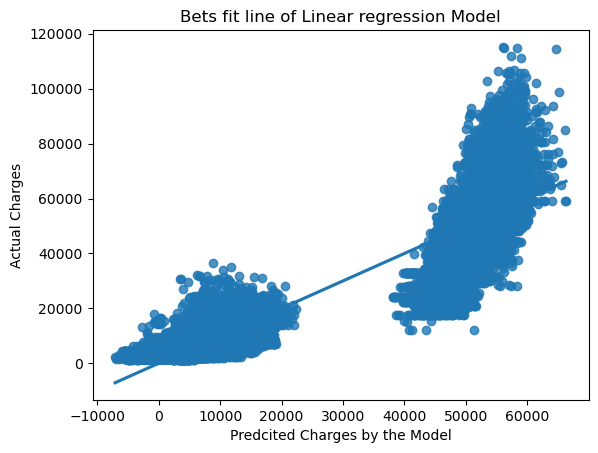

In [41]:
sns.regplot(x=y_pred,y=y_test)
plt.xlabel('Predcited Charges by the Model')
plt.ylabel('Actual Charges')
plt.title('Bets fit line of Linear regression Model')
plt.show()

In [42]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=73)

In [43]:
dt_model.fit(x_train_scaled,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,73
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [44]:
#Test the Model
y_pred_dt=dt_model.predict(x_test_scaled)

In [45]:
y_pred_dt

array([ 7366., 72783.,  6195., ...,  6314.,  4558., 70049.],
      shape=(60031,))

In [46]:
mean_squared_error(y_test,y_pred_dt)

12592977.692723574

In [47]:
r2_score(y_test,y_pred_dt)

0.97557049322853

In [48]:
rmse_dt = np.sqrt(mean_squared_error(y_test,y_pred_dt))
rmse_dt

np.float64(3548.6585765220602)